# Module 06: OpenCV for Computer Vision & Machine Learning
## Notebook 03: Spatial Filtering, Denoising, and Mathematical Morphology

Image filtering is the bedrock of spatial feature extraction and signal conditioning. Filtering computes new pixel values through local neighborhood operations (2D convolutions), allowing us to denoise sensor data, isolate sharp boundaries, and clean structured binary shapes.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Understand the mathematical mechanism of **2D Spatial Convolution** and design custom linear kernels with `cv2.filter2D()`.
2. Compare linear smoothing filters: **Normalized Box Blur** (`cv2.blur`) vs. **Gaussian Blur** (`cv2.GaussianBlur`).
3. Apply non-linear **Median Filtering** (`cv2.medianBlur`) and benchmark its effectiveness against impulse salt-and-pepper noise.
4. Segment images using **Global**, **Adaptive**, and **Otsu's Bimodal Automatic Thresholding**.
5. Apply fundamental mathematical morphological operations: **Erosion**, **Dilation**, **Opening**, **Closing**, and **Top-Hat** transforms.
6. **Advanced:** Preserve critical edge boundaries while smoothing noise using non-linear **Bilateral Filtering** (`cv2.bilateralFilter`).
7. **Advanced:** Build a production **Document Illumination Normalization Pipeline** to remove severe shadow gradients using morphological background subtraction.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_dir = "images" if os.path.exists("images") else "../images"
print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 5.0.0


### 1. 2D Spatial Convolution & Custom Linear Kernels
In image processing, spatial convolution slides a small matrix of weights (kernel $K$ of size $k \times k$) across an image $I$:
$$I'(x, y) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} I(x - i, y - j) \cdot K(i, j)$$
- `cv2.filter2D(src, ddepth=-1, kernel)` executes linear convolution.
- Common kernels:
  - **Identity Kernel:** leaves pixel values unchanged.
  - **Sharpening Kernel:** $\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$ (amplifies high-frequency differences).
  - **Laplacian Ridge / Edge Kernel:** $\begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix}$ (sums to 0, responds only to discontinuities).

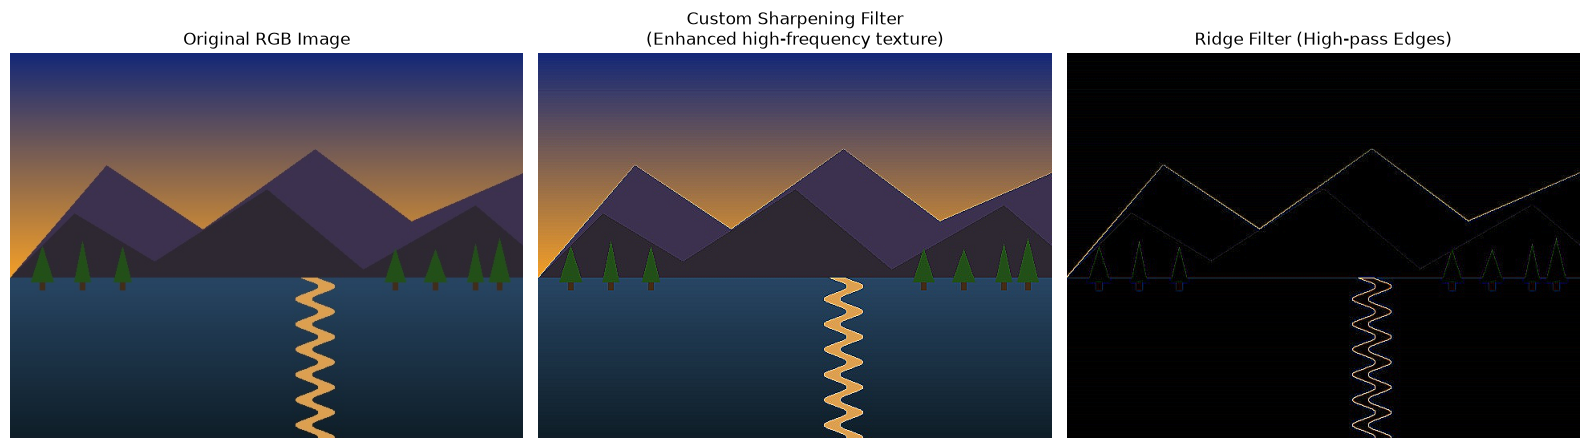

In [2]:
# Load test landscape
landscape_bgr = cv2.imread(os.path.join(img_dir, "landscape.jpg"))
landscape_rgb = cv2.cvtColor(landscape_bgr, cv2.COLOR_BGR2RGB)

# 1. Sharpening Kernel
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# 2. High-pass Ridge Detection Kernel
kernel_ridge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# Apply 2D convolution
sharpened = cv2.filter2D(landscape_rgb, -1, kernel_sharpen)
ridge_edges = cv2.filter2D(landscape_rgb, -1, kernel_ridge)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(landscape_rgb)
axes[0].set_title("Original RGB Image")
axes[0].axis("off")

axes[1].imshow(sharpened)
axes[1].set_title("Custom Sharpening Filter\n(Enhanced high-frequency texture)")
axes[1].axis("off")

axes[2].imshow(ridge_edges)
axes[2].set_title("Ridge Filter (High-pass Edges)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 2. Smoothing & Denoising: Gaussian vs. Median Filter Benchmark
Denoising is vital before feature extraction:
- **Gaussian Blur (`cv2.GaussianBlur`):** Convolves with a 2D Gaussian bell-curve kernel:
  $$G(x, y) = \frac{1}{2\pi \sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$
  Optimal for suppressing zero-mean additive Gaussian sensor noise.
- **Median Filter (`cv2.medianBlur`):** Replaces each pixel with the statistical **median** of its neighborhood. Because median is rank-based (not an arithmetic average), outliers (extreme black or white noise spikes) are completely eliminated without blurring sharp edges.

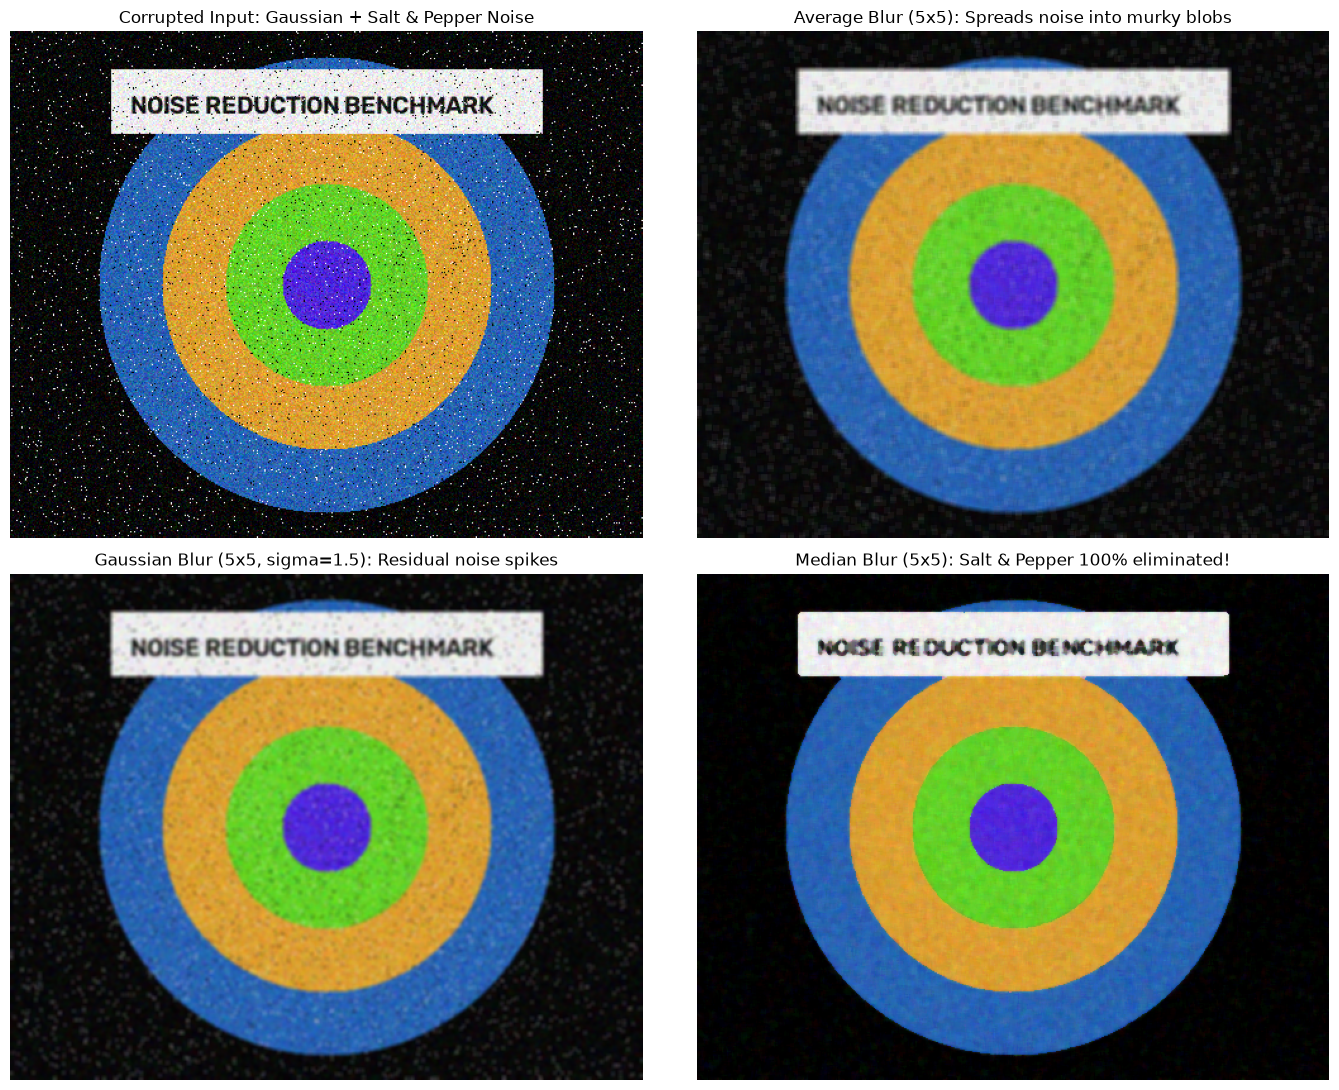

In [3]:
# Load noisy test benchmark (contains Gaussian noise + 3% salt-and-pepper noise)
noisy_bgr = cv2.imread(os.path.join(img_dir, "noisy_sample.png"))
noisy_rgb = cv2.cvtColor(noisy_bgr, cv2.COLOR_BGR2RGB)

# 1. Average Blur
blur_avg = cv2.blur(noisy_rgb, (5, 5))

# 2. Gaussian Blur
blur_gauss = cv2.GaussianBlur(noisy_rgb, (5, 5), sigmaX=1.5)

# 3. Median Blur (Kernel size must be an odd integer, e.g. 5)
blur_median = cv2.medianBlur(noisy_rgb, 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].imshow(noisy_rgb)
axes[0, 0].set_title("Corrupted Input: Gaussian + Salt & Pepper Noise")
axes[0, 0].axis("off")

axes[0, 1].imshow(blur_avg)
axes[0, 1].set_title("Average Blur (5x5): Spreads noise into murky blobs")
axes[0, 1].axis("off")

axes[1, 0].imshow(blur_gauss)
axes[1, 0].set_title("Gaussian Blur (5x5, sigma=1.5): Residual noise spikes")
axes[1, 0].axis("off")

axes[1, 1].imshow(blur_median)
axes[1, 1].set_title("Median Blur (5x5): Salt & Pepper 100% eliminated!")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 3. Thresholding: Global, Adaptive & Otsu's Method
Thresholding converts grayscale images into binary masks ($0$ or $255$):
- **Global Thresholding (`cv2.threshold`):** Applies fixed cutoff $T$:
  $$\text{dst}(x, y) = \begin{cases} \text{maxVal} & \text{if } \text{src}(x, y) > T \\ 0 & \text{otherwise} \end{cases}$$
- **Adaptive Thresholding (`cv2.adaptiveThreshold`):** Calculates a threshold dynamically for each pixel based on a local neighborhood ($B \times B$). Solves non-uniform illumination and cast shadows.
- **Otsu's Bimodal Thresholding (`THRESH_OTSU`):** Automatically finds the optimal global threshold $T^*$ that minimizes the weighted intra-class variance $\sigma_w^2(T) = q_1(T)\sigma_1^2(T) + q_2(T)\sigma_2^2(T)$.

Otsu's calculated optimal threshold: 110.0


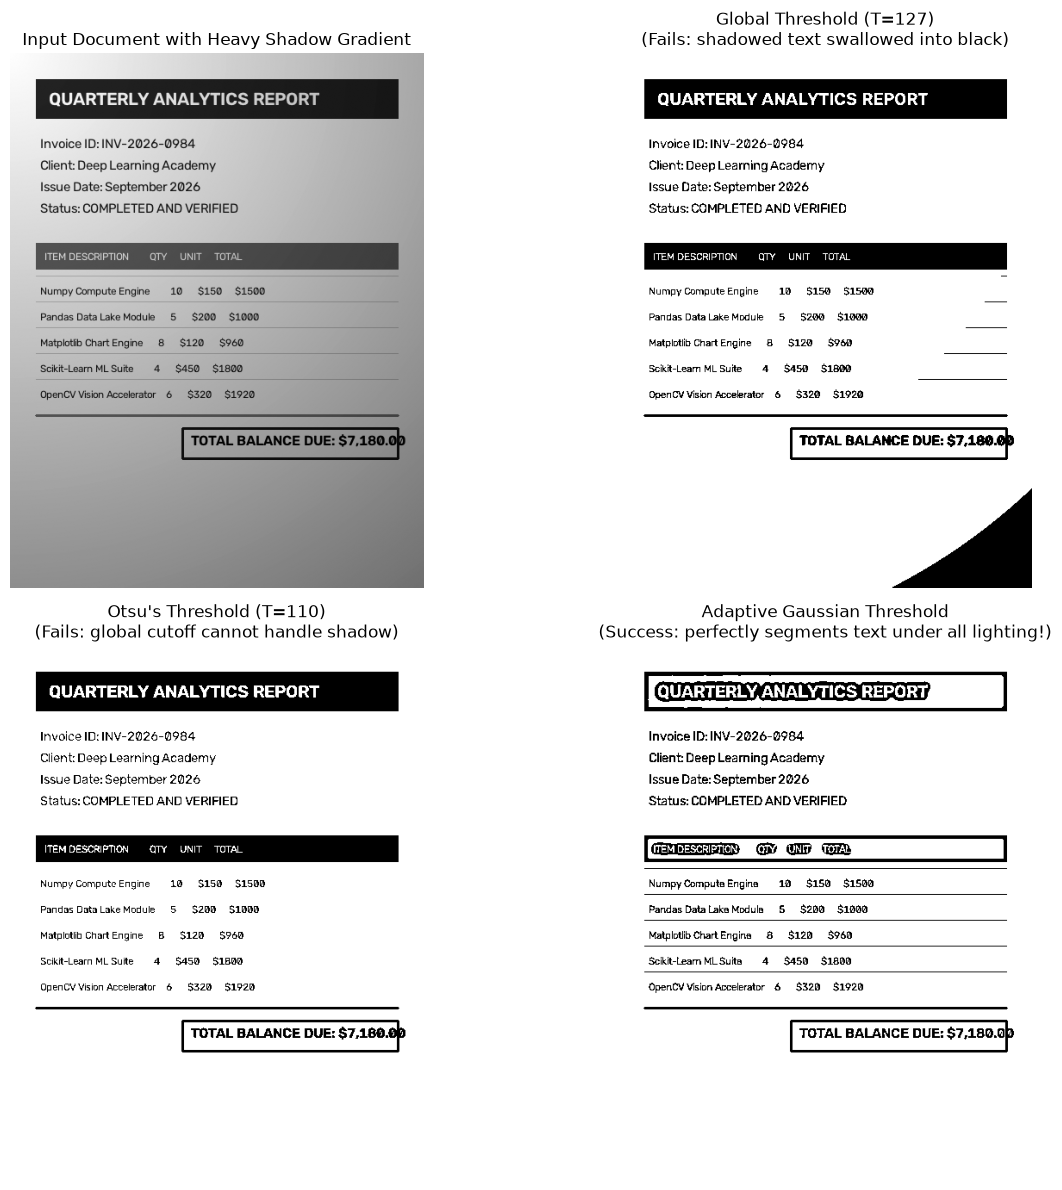

In [4]:
# Load document containing a severe illumination shadow gradient
doc_gray = cv2.imread(os.path.join(img_dir, "document.png"), cv2.IMREAD_GRAYSCALE)

# 1. Global fixed threshold (T = 127)
_, thresh_global = cv2.threshold(doc_gray, 127, 255, cv2.THRESH_BINARY)

# 2. Otsu's Automatic Thresholding
otsu_val, thresh_otsu = cv2.threshold(doc_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu's calculated optimal threshold: {otsu_val:.1f}")

# 3. Adaptive Thresholding (Gaussian neighborhood, blockSize=15, C=8)
thresh_adaptive = cv2.adaptiveThreshold(
    doc_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=15, C=8
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(doc_gray, cmap="gray")
axes[0, 0].set_title("Input Document with Heavy Shadow Gradient")
axes[0, 0].axis("off")

axes[0, 1].imshow(thresh_global, cmap="gray")
axes[0, 1].set_title("Global Threshold (T=127)\n(Fails: shadowed text swallowed into black)")
axes[0, 1].axis("off")

axes[1, 0].imshow(thresh_otsu, cmap="gray")
axes[1, 0].set_title(f"Otsu's Threshold (T={otsu_val:.0f})\n(Fails: global cutoff cannot handle shadow)")
axes[1, 0].axis("off")

axes[1, 1].imshow(thresh_adaptive, cmap="gray")
axes[1, 1].set_title("Adaptive Gaussian Threshold\n(Success: perfectly segments text under all lighting!)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 4. Mathematical Morphology: Structuring Elements and Operations
Mathematical morphology probes geometrical structures with a **Structuring Element (Kernel)**:
- `cv2.getStructuringElement(shape, ksize)`: shape can be `cv2.MORPH_RECT`, `cv2.MORPH_ELLIPSE`, or `cv2.MORPH_CROSS`.
- **Erosion (`cv2.erode`):** Shrinks foreground boundaries; strips isolated foreground noise points.
- **Dilation (`cv2.dilate`):** Expands foreground boundaries; bridges small breaks in lines.
- **Opening (`cv2.MORPH_OPEN`):** Erosion followed by Dilation. Removes small foreground background noise without changing object size.
- **Closing (`cv2.MORPH_CLOSE`):** Dilation followed by Erosion. Fills small interior pinholes and connects disjoint components.
- **Morphological Gradient (`cv2.MORPH_GRADIENT`):** Difference between Dilation and Erosion ($\text{Dilate} - \text{Erode}$); yields the contour outline.

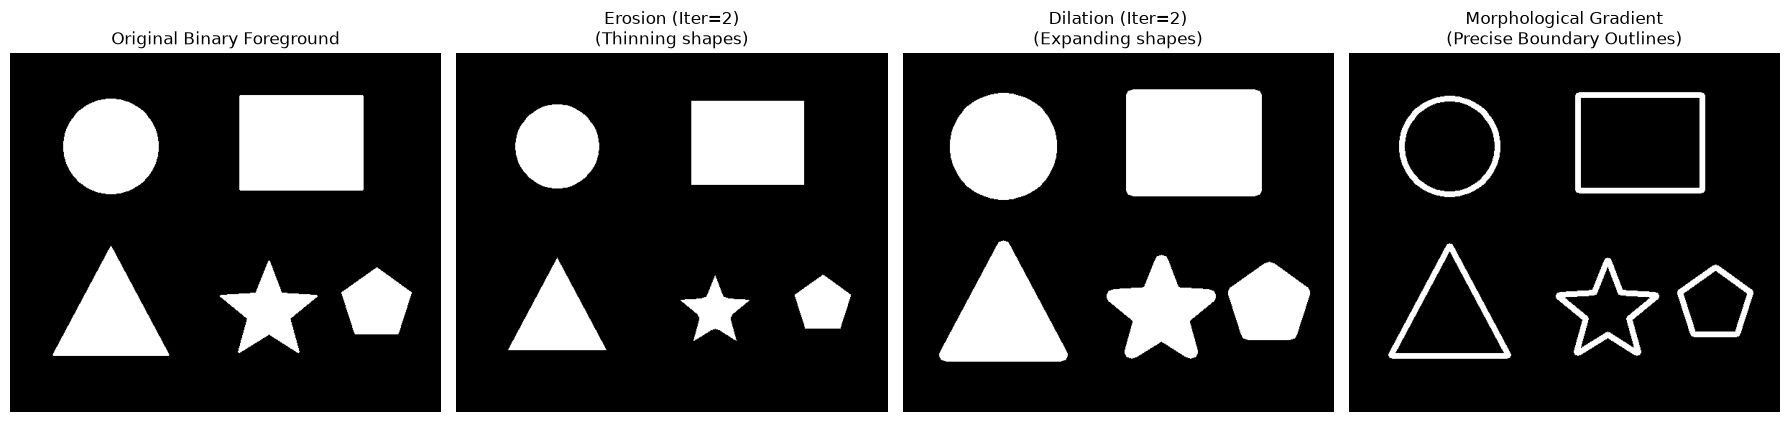

In [5]:
# Load shapes image and create an inverted binary mask
shapes_bgr = cv2.imread(os.path.join(img_dir, "shapes.png"))
shapes_gray = cv2.cvtColor(shapes_bgr, cv2.COLOR_BGR2GRAY)
_, shapes_bin = cv2.threshold(shapes_gray, 240, 255, cv2.THRESH_BINARY_INV)

# Define structuring element
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

# Execute morphological operators
eroded = cv2.erode(shapes_bin, se, iterations=2)
dilated = cv2.dilate(shapes_bin, se, iterations=2)
morph_grad = cv2.morphologyEx(shapes_bin, cv2.MORPH_GRADIENT, se)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(shapes_bin, cmap="gray")
axes[0].set_title("Original Binary Foreground")
axes[0].axis("off")

axes[1].imshow(eroded, cmap="gray")
axes[1].set_title("Erosion (Iter=2)\n(Thinning shapes)")
axes[1].axis("off")

axes[2].imshow(dilated, cmap="gray")
axes[2].set_title("Dilation (Iter=2)\n(Expanding shapes)")
axes[2].axis("off")

axes[3].imshow(morph_grad, cmap="gray")
axes[3].set_title("Morphological Gradient\n(Precise Boundary Outlines)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 5. Complex Application 1: Edge-Preserving Bilateral Filtering
Standard Gaussian filtering blurs across edge boundaries because it only measures spatial distance.
**Bilateral Filtering (`cv2.bilateralFilter`)** uses two Gaussian components:
$$I^{\text{filtered}}(p) = \frac{1}{W_p} \sum_{q \in S} I(q) \cdot G_{\sigma_s}(\|p - q\|) \cdot G_{\sigma_r}(\|I(p) - I(q)\|)$$
1. **Spatial Gaussian ($G_{\sigma_s}$):** Weights nearby pixels higher based on geometric distance.
2. **Radiometric Range Gaussian ($G_{\sigma_r}$):** Weights pixels higher *only if their color/intensity is similar* to the center pixel.
- **Result:** High-frequency surface textures (skin blemishes, camera sensor grain) are completely smoothed while high-contrast edges remain razor-sharp.

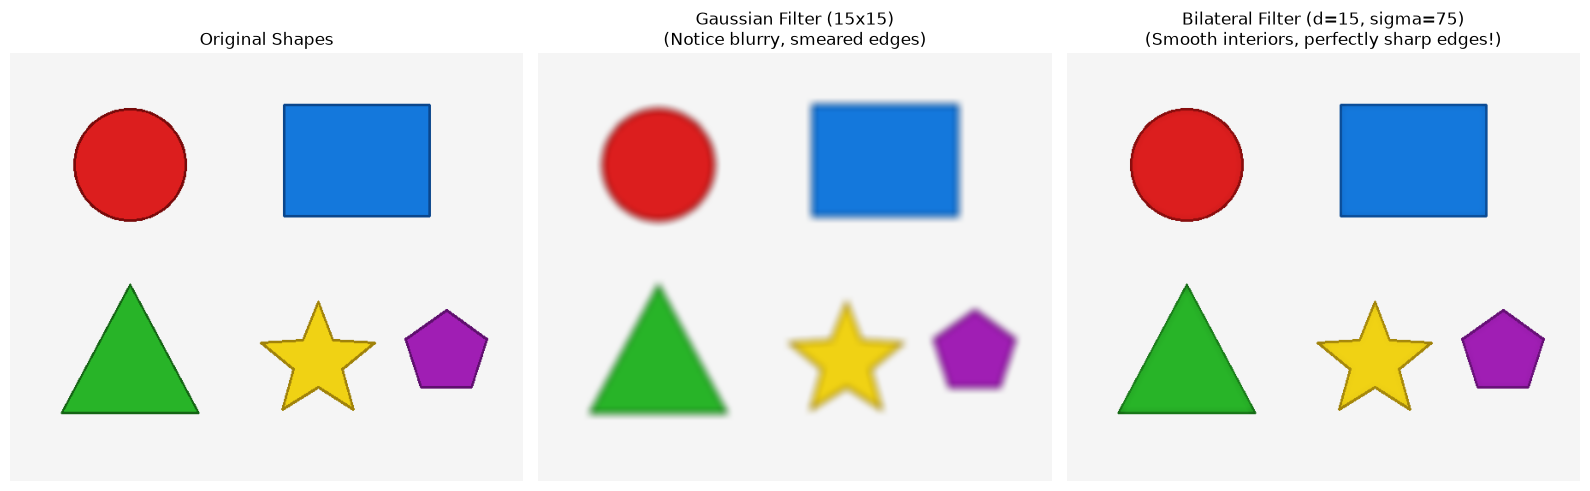

In [6]:
# Compare Gaussian Blur vs Bilateral Filter on the shapes image
shapes_rgb = cv2.cvtColor(shapes_bgr, cv2.COLOR_BGR2RGB)

# 1. Heavy Gaussian Blur
heavy_gauss = cv2.GaussianBlur(shapes_rgb, (15, 15), sigmaX=5.0)

# 2. Bilateral Filter: d=15, sigmaColor=75, sigmaSpace=75
bilateral = cv2.bilateralFilter(shapes_rgb, d=15, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(shapes_rgb)
axes[0].set_title("Original Shapes")
axes[0].axis("off")

axes[1].imshow(heavy_gauss)
axes[1].set_title("Gaussian Filter (15x15)\n(Notice blurry, smeared edges)")
axes[1].axis("off")

axes[2].imshow(bilateral)
axes[2].set_title("Bilateral Filter (d=15, sigma=75)\n(Smooth interiors, perfectly sharp edges!)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 6. Complex Application 2: Document Illumination Normalization Pipeline
Uneven shadows ruin OCR (Optical Character Recognition) and machine learning models.
We can construct a morphological illumination correction pipeline:
1. Use **Morphological Opening** with a very large kernel ($50 \times 50$) to erase text while preserving the slowly-varying background illumination field.
2. Divide the original image by the estimated background illumination map:
   $$I_{\text{normalized}} = \frac{I}{\text{Background}} \times 255$$
3. Result: Perfectly flat, uniform background illumination across the entire document page.

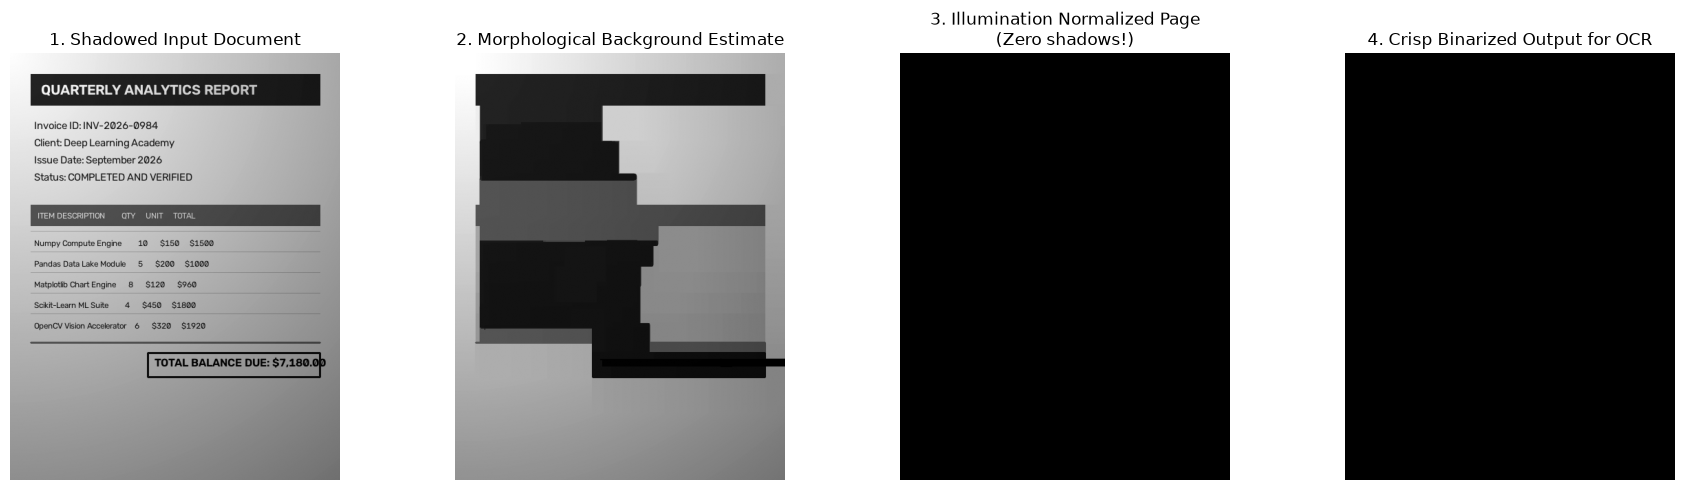

In [7]:
# 1. Read shadowed document in grayscale
doc = cv2.imread(os.path.join(img_dir, "document.png"), cv2.IMREAD_GRAYSCALE)

# 2. Estimate background illumination field using large morphological opening
kernel_large = cv2.getStructuringElement(cv2.MORPH_RECT, (51, 51))
background = cv2.morphologyEx(doc, cv2.MORPH_OPEN, kernel_large)

# 3. Normalize illumination via float division
# Avoid division by zero by clipping background minimum
bg_safe = np.maximum(background.astype(np.float32), 1.0)
normalized = np.clip((doc.astype(np.float32) / bg_safe) * 255.0, 0, 255).astype(np.uint8)

# 4. Standard global threshold on the normalized document now works flawlessly
_, clean_thresh = cv2.threshold(normalized, 220, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(doc, cmap="gray")
axes[0].set_title("1. Shadowed Input Document")
axes[0].axis("off")

axes[1].imshow(background, cmap="gray")
axes[1].set_title("2. Morphological Background Estimate")
axes[1].axis("off")

axes[2].imshow(normalized, cmap="gray")
axes[2].set_title("3. Illumination Normalized Page\n(Zero shadows!)")
axes[2].axis("off")

axes[3].imshow(clean_thresh, cmap="gray")
axes[3].set_title("4. Crisp Binarized Output for OCR")
axes[3].axis("off")

plt.tight_layout()
plt.show()